In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import signature_pricing_py as pricing_py
import signature_core_py as core_py
from signature_core import *
from processes import *
import plotly.graph_objects as go
import signature_pricing_cpp as pricing_cpp
import signature_core as core_cpp
import processes

plt.rcParams['figure.dpi'] = 100
generate_new_images = False

In [3]:
trunc = 1 # to be able to plot in 3D
u_values = [1.0, 2.0, 3.0, 4, 5, 6, 7]
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3', '#FF6692']
color_map = dict(zip(u_values, colors))

In [4]:
def simulate_psi_rk4_test(psi_0: Sig, u: float, maturity: float, model_sig: Sig, model_sig_squared, rk_subdivs: int, rho: float, trunc: int):
    psi = psi_0.copy()
    dt = float(maturity / rk_subdivs)

    points = np.zeros( (rk_subdivs, 3), dtype=np.complex128 )

    for i in range(rk_subdivs):
        k1 = pricing_py.psi_derivative(u, i*dt, psi, model_sig, model_sig_squared, rho, trunc)
        k2 = pricing_py.psi_derivative(u, i*dt+dt/2, psi + 0.5*dt*k1, model_sig, model_sig_squared, rho, trunc)
        k3 = pricing_py.psi_derivative(u, i*dt+dt/2, psi + 0.5*dt*k2, model_sig, model_sig_squared, rho, trunc)
        k4 = pricing_py.psi_derivative(u, (i+1)*dt, psi + dt*k3, model_sig, model_sig_squared, rho, trunc)

        psi = psi + (dt/6)*(k1 + 2*k2 + 2*k3 +k4 )

        points[i, :] = [psi.data[0], psi.data[1][0], psi.data[1][1]]

    return points

In [5]:
def solve(u, rk_subdivs, tensor_list):
    psi0 = core_py.Sig([], 2, dtype=np.complex128)
    model_sig_py = core_py.Sig(tensor_list, 2, np.complex128)
    model_sig_squared_py = model_sig_py.shuffle(model_sig_py, trunc)

    return simulate_psi_rk4_test(psi0, u-0.5j, 1.0, model_sig_py, model_sig_squared_py, rk_subdivs, -0.2, trunc)


In [6]:
fig = go.Figure()

np.random.seed(0xDEADBEEF)
for u in u_values[-1:]:
    
    for i in range(5):
        show_legend = True if i == 0 else False
        color = colors[i]
        
        tensor_list = [10 * np.random.random( (2,)*i) for i in range(trunc+1)]
        points = np.real( solve(u, 100, tensor_list) )
        x_vals = points[:, 0]
        y_vals = points[:, 1]
        z_vals = points[:, 2]
        
        fig.add_trace(go.Scatter3d(
            x=x_vals, y=y_vals, z=z_vals,
            mode='lines+markers',
            line=dict(color=color, width=3),
            name=f"u = {u}",
            marker=dict(
                size=3, symbol='circle', opacity=0.7,
                line=dict(color='black', width=0.5)
            ),
            legendgroup=f"group_{u}", showlegend=show_legend
        ))

fig.update_layout(
    title='3D Trajectories Modulus Analysis',
    scene=dict( xaxis_title='|X|', yaxis_title='|Y|', zaxis_title='|Z|', aspectmode='cube' ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [7]:
fig = go.Figure()

np.random.seed(0xDEADBEEF)
u = u_values[-1]
tensor_list = [10 * np.ones( (2,)*i) for i in range(trunc+1)]

fig.add_trace(go.Scatter3d(
    x=[tensor_list[0]], y=[tensor_list[1][0]], z=[tensor_list[1][1]],
    mode='markers',
    line=dict(color='#ff0000', width=3),
    name=f"Initial Point",
    marker=dict(
        size=4, symbol='circle', opacity=1.0,
        line=dict(color='black', width=0.5)
    ),
    legendgroup=f"group_{u}", showlegend=True
))

for k, rk_sub in enumerate([10, 20, 100]):
    color = colors[k]
    points = np.real( solve(u*1.1, rk_sub, tensor_list) )
    x_vals = points[:, 0]
    y_vals = points[:, 1]
    z_vals = points[:, 2]
    
    fig.add_trace(go.Scatter3d(
        x=x_vals, y=y_vals, z=z_vals,
        mode='lines+markers',
        line=dict(color=color, width=3),
        name=f"rk_subdivs = {rk_sub}",
        marker=dict(
            size=3, symbol='circle', opacity=0.7,
            line=dict(color='black', width=0.5)
        ),
        legendgroup=f"group_{u}", showlegend=True
    ))

fig.update_layout(
    title='3D Trajectories Modulus Analysis',
    scene=dict( xaxis_title='|X|', yaxis_title='|Y|', zaxis_title='|Z|', aspectmode='cube' ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [8]:
fig = go.Figure()

np.random.seed(0xDEADBEEF)
tensor_list = [10 * np.ones( (2,)*i) for i in range(trunc+1)]

fig.add_trace(go.Scatter3d(
    x=[tensor_list[0]], y=[tensor_list[1][0]], z=[tensor_list[1][1]],
    mode='markers',
    line=dict(color='#ff0000', width=3),
    name=f"Initial Point",
    marker=dict(
        size=4, symbol='circle', opacity=1.0,
        line=dict(color='black', width=0.5)
    ),
    legendgroup=f"group_{u}", showlegend=True
))

for u in u_values:
    color = color_map[u]

    points = np.real( solve(u, 50, tensor_list) )
    x_vals = points[:, 0]
    y_vals = points[:, 1]
    z_vals = points[:, 2]
    
    fig.add_trace(go.Scatter3d(
        x=x_vals, y=y_vals, z=z_vals,
        mode='lines+markers',
        line=dict(color=color, width=3),
        name=f"u = {u}",
        marker=dict(
            size=3, symbol='circle', opacity=0.7,
            line=dict(color='black', width=0.5)
        ),
        legendgroup=f"group_{u}", showlegend=True
    ))

fig.update_layout(
    title='3D Trajectories Modulus Analysis',
    scene=dict( xaxis_title='|X|', yaxis_title='|Y|', zaxis_title='|Z|', aspectmode='cube' ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [9]:
# (100, 0.058333333333333334, 70.0, <signature_core.signature_core_cpp.Sig2D object at 0x7f417b67e1f0>, -0.2, 1, 15, 20, <signature_core.signature_core_cpp.ShuffleCache object at 0x7f417b62e0f0>)


In [10]:
trunc = 1
model_sig = core_cpp.Sig2D(trunc, [0.2, -2.0, 1.0])
model_sig_py = core_py.Sig([np.array(0.2), np.array([-2.0, 1.0])], 2, np.complex128)
cpp_cache = core_cpp.compute_shuffle_cache(trunc)

initial_price = 100
strike = 70.0
maturity = 0.058333
rho = -0.2
rk_subdivs = 15
k_0 = np.log(initial_price / strike)

model_sig_squared = core_cpp.shuffle(model_sig, model_sig, trunc, cpp_cache)
upper_bound = 500.0

def integrand_py(u, rk_subdivs, tensor_list):
    psi0 = core_py.Sig([], 2, dtype=np.complex128)
    model_sig_py = core_py.Sig(tensor_list, 2, np.complex128)
    model_sig_squared_py = model_sig_py.shuffle(model_sig_py, trunc)

    res = simulate_psi_rk4_test(psi0, u-0.5j, 1.0, model_sig_py, model_sig_squared_py, rk_subdivs, -0.2, trunc)

    return res[-1]

def integrand(u):
    return core_cpp.european_call_integrand(
        u, k_0, maturity, model_sig, model_sig_squared, 
        rho, trunc, rk_subdivs, upper_bound, cpp_cache
    )

In [11]:
integrand_py(100, 20, model_sig_py.data)

array([-4533.86927284-356.55130114j,   138.63902746-117.41455883j,
         -69.31951373 +58.70727941j])

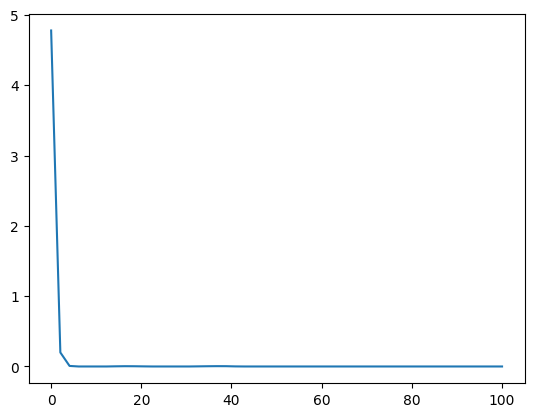

In [12]:
us = np.linspace(0.01, 100, 50)
ys = [integrand(u) for u in us]
plt.plot(us, ys)